In [193]:
import random
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from scipy.stats import spearmanr

SEED = 42
MIN_OBSERVED_TARGETS = 2
LOW_OBS_THRESHOLD = 30
IPS_MIN_PROBA = 0.05
IPS_MAX_WEIGHT = 6.0
ARCHETYPE_HIGH_SUPPORT = 20
ARCHETYPE_MEDIUM_SUPPORT = 8
ARCHETYPE_LOW_SUPPORT = 3

PERIOD_BUCKETS = ["pre_1945", "1945_1970", "1970_1990", "1990_2010", "post_2010"]
X_cols = [
    "Construction period",
    "Construction period bucket",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Country",
    "Geo_macro",
]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]
archetype_cols = [
    "Construction period bucket",
    "Typology",
    "Primary Code",
    "Country",
]


def to_period_bucket(year_series):
    year = pd.to_numeric(year_series, errors="coerce")
    return pd.cut(
        year,
        bins=[-np.inf, 1945, 1970, 1990, 2010, np.inf],
        labels=PERIOD_BUCKETS,
        right=False,
    )

def archetype_support_level(n_rows):
    if n_rows >= ARCHETYPE_HIGH_SUPPORT:
        return "high"
    if n_rows >= ARCHETYPE_MEDIUM_SUPPORT:
        return "medium"
    if n_rows >= ARCHETYPE_LOW_SUPPORT:
        return "low"
    if n_rows >= 1:
        return "very_low"
    return "none"

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports complete.  SEED =", SEED)

# -- Visualisation style constants --
_C1   = "#4C72B0"   # main blue
_C2   = "#DD8452"   # accent orange
_REF  = "#C44E52"   # reference-line red
_GRAY = "#AAAAAA"

plt.rcParams.update({
    "figure.dpi":         110,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "legend.fontsize":   11,
})

Imports complete.  SEED = 42


In [169]:
# ==========================================================
# Data Preparation
# ==========================================================


def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df["Construction period bucket"] = to_period_bucket(df["Construction period"])
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64).copy()
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64).copy()
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64).copy()

    # Cap y_train at per-material p99.5 (training obs only — no leakage).
    # Val/test targets stay raw for honest evaluation.
    for m in range(len(y_cols)):
        obs = y_train_mask[:, m]
        if obs.sum() < 2:
            continue
        cap = np.nanpercentile(y_train_raw[obs, m], 99.5)
        y_train_raw[obs, m] = np.minimum(y_train_raw[obs, m], cap)

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Construction period bucket", "Typology", "Primary Code", "Hybrid Structure", "Country", "Geo_macro"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        preprocessor=preprocessor,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )

In [170]:
# ==========================================================
# Archetype Support Diagnostics (training split)
# ==========================================================
# This cell is only for checking whether the current thresholds are reasonable.
# It does not affect model training.

archetype_counts = (
    data["X_train_raw"][archetype_cols]
    .astype("string")
    .groupby(archetype_cols)
    .size()
    .sort_values(ascending=False)
)

print("Archetype support diagnostics (training split)")
print(f"Unique archetypes: {len(archetype_counts)}")
print(f"Total training rows: {len(data['X_train_raw'])}")
print()
print("Distribution of rows per archetype:")
print(
    archetype_counts
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
    .to_string()
)

def support_distribution(counts, low, medium, high):
    """Return number of archetypes in each support band."""
    return pd.Series({
        "very_low": (counts < low).sum(),
        "low":      ((counts >= low)    & (counts < medium)).sum(),
        "medium":   ((counts >= medium) & (counts < high)).sum(),
        "high":     (counts >= high).sum(),
    })

support_summary = support_distribution(
    archetype_counts,
    ARCHETYPE_LOW_SUPPORT,
    ARCHETYPE_MEDIUM_SUPPORT,
    ARCHETYPE_HIGH_SUPPORT,
)

print()
print("=" * 70)
print(f"LOW    = {ARCHETYPE_LOW_SUPPORT}")
print(f"MEDIUM = {ARCHETYPE_MEDIUM_SUPPORT}")
print(f"HIGH   = {ARCHETYPE_HIGH_SUPPORT}")
print()
print(support_summary.to_string())
print("=" * 70)
print(f"< {ARCHETYPE_LOW_SUPPORT} rows: weak archetype evidence")
print(f"{ARCHETYPE_LOW_SUPPORT}-{ARCHETYPE_MEDIUM_SUPPORT - 1} rows: limited archetype evidence")
print(f"{ARCHETYPE_MEDIUM_SUPPORT}-{ARCHETYPE_HIGH_SUPPORT - 1} rows: moderate archetype evidence")
print(f"≥ {ARCHETYPE_HIGH_SUPPORT} rows: strong archetype evidence")
print()
print("Top 10 archetype supports:")
print(archetype_counts.head(10).to_string())
print()
print(f"Median archetype support: {int(archetype_counts.median())} rows")

Archetype support diagnostics (training split)
Unique archetypes: 215
Total training rows: 1799

Distribution of rows per archetype:
count    215.000000
mean       8.367442
std       21.271495
min        1.000000
10%        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
90%       18.000000
95%       43.900000
max      158.000000

LOW    = 3
MEDIUM = 8
HIGH   = 20

very_low    139
low          39
medium       16
high         21
< 3 rows: weak archetype evidence
3-7 rows: limited archetype evidence
8-19 rows: moderate archetype evidence
≥ 20 rows: strong archetype evidence

Top 10 archetype supports:
Construction period bucket  Typology  Primary Code  Country
1990_2010                   R-UNK     B             China      158
                            NR-C      C             China      150
1970_1990                   R-UNK     B             China      128
1990_2010                   R-AB      C             China       77
                                      B     

In [171]:
# ==========================================================
# Export archetypes by support level to Excel
# ==========================================================

from datetime import datetime as _dt

archetype_df = archetype_counts.reset_index()
archetype_df.columns = list(archetype_cols) + ["n_train"]
archetype_df["support_level"] = archetype_df["n_train"].apply(archetype_support_level)

level_order = {"high": 0, "medium": 1, "low": 2, "very_low": 3}
archetype_df["_order"] = archetype_df["support_level"].map(level_order)
archetype_df = archetype_df.sort_values(["_order", "n_train"], ascending=[True, False]).drop(columns="_order").reset_index(drop=True)

out_path = Path(f"archetype_support_levels_{_dt.now().strftime('%Y%m%d_%H%M%S')}.xlsx")

with pd.ExcelWriter(out_path) as writer:
    for level in ["high", "medium", "low", "very_low"]:
        subset = archetype_df[archetype_df["support_level"] == level].drop(columns="support_level").reset_index(drop=True)
        subset.to_excel(writer, sheet_name=level, index=False)
    archetype_df.to_excel(writer, sheet_name="all", index=False)

print(f"Saved → {out_path}")
for level in ["high", "medium", "low", "very_low"]:
    n = (archetype_df["support_level"] == level).sum()
    threshold = {
        "high":     f"≥{ARCHETYPE_HIGH_SUPPORT} rows",
        "medium":   f"{ARCHETYPE_MEDIUM_SUPPORT}–{ARCHETYPE_HIGH_SUPPORT - 1} rows",
        "low":      f"{ARCHETYPE_LOW_SUPPORT}–{ARCHETYPE_MEDIUM_SUPPORT - 1} rows",
        "very_low": f"1–{ARCHETYPE_LOW_SUPPORT - 1} rows",
    }[level]
    print(f"  {level:<10} ({threshold}): {n} archetypes")

Saved → archetype_support_levels_20260610_161407.xlsx
  high       (≥20 rows): 21 archetypes
  medium     (8–19 rows): 16 archetypes
  low        (3–7 rows): 39 archetypes
  very_low   (1–2 rows): 139 archetypes


In [172]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

Data preparation complete.
X_train: (1799, 61)  y_train: (1799, 5)
X_val:   (385, 61)  y_val:   (385, 5)
X_test:  (386, 61)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)


### Data Interpretation

Material intensity columns contain reported numeric values (typically positive) or missing values. Missing values are not interpreted as zero or as confirmed material absence. They reflect database incompleteness: a survey may not have recorded every material for every building.

This notebook estimates reported material intensity patterns from an incomplete database. The model supports database querying, gap exploration, and early-stage estimation, not verification of true physical material stocks.

**Stage 1** (`ObservationModel`)  predicts P(recorded | x): the probability that the database contains an intensity value for a given material in a building with features x.

**Stage 2** (`IntensityModel`)  estimates the intensity value (kg/m²), conditioned on the material being recorded, using quantile regression. Stage 1 recording probabilities are not appended as Stage 2 features; they are used only as inverse-propensity sample weights during Stage 2 training.

The main workflow uses raw observed material intensity values. Extreme values are retained because they are part of the reported database. Log transformation (log1p) is used to reduce skewness during model fitting.

In [173]:
# ==========================================================
# Missingness / Observation Rate Summary
# ==========================================================

header = (f"{'Material':<12}  {'n_train':>8}  {'obs%_train':>10}  "
          f"{'n_val':>6}  {'obs%_val':>8}  {'n_test':>7}  {'obs%_test':>9}")
print(header)
print("-" * len(header))

for m, mat in enumerate(y_cols):
    n_tr = int(data['y_train_mask'][:, m].sum())
    n_v  = int(data['y_val_mask'][:, m].sum())
    n_te = int(data['y_test_mask'][:, m].sum())
    r_tr = n_tr / len(data['y_train_mask']) * 100
    r_v  = n_v  / len(data['y_val_mask'])   * 100
    r_te = n_te / len(data['y_test_mask'])  * 100
    print(f"{mat:<12}  {n_tr:>8}  {r_tr:>9.1f}%  "
          f"{n_v:>6}  {r_v:>7.1f}%  {n_te:>7}  {r_te:>8.1f}%")


Material       n_train  obs%_train   n_val  obs%_val   n_test  obs%_test
------------------------------------------------------------------------
Concrete          1385       77.0%     282     73.2%      297      76.9%
Glass              886       49.2%     176     45.7%      193      50.0%
Steel             1638       91.1%     344     89.4%      346      89.6%
Wood              1452       80.7%     316     82.1%      313      81.1%
Brick             1200       66.7%     257     66.8%      277      71.8%


In [174]:
# ==========================================================
# Data Quality: Extreme Value Diagnostic
# ==========================================================
# Extreme values are RETAINED in the main model.
# This table flags records above the 99th percentile
# for awareness only. No values are removed or altered.

print("Extreme value diagnostic — all rows combined (train + val + test)")
print("Extreme values are retained in training, evaluation, and visualisations.")
print()
print(f"{'Material':<12}  {'n_obs':>6}  {'p99 (kg/m2)':>12}  {'max (kg/m2)':>12}  {'n_above_p99':>12}  {'pct_above':>10}")
print("-" * 72)

y_all_raw  = np.vstack([data["y_train_raw"],  data["y_val_raw"],  data["y_test_raw"]])
y_all_mask = np.vstack([data["y_train_mask"], data["y_val_mask"], data["y_test_mask"]])

for m, mat in enumerate(y_cols):
    obs = y_all_mask[:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  insufficient data")
        continue
    vals    = y_all_raw[obs, m]
    p99     = np.percentile(vals, 99)
    vmax    = vals.max()
    n_above = int((vals > p99).sum())
    pct     = n_above / len(vals) * 100
    flag    = "  <-- review" if vmax > p99 * 5 else ""
    print(f"{mat:<12}  {int(obs.sum()):>6}  {p99:>12.1f}  {vmax:>12.1f}  "
          f"{n_above:>12}  {pct:>9.1f}%{flag}")

Extreme value diagnostic — all rows combined (train + val + test)
Extreme values are retained in training, evaluation, and visualisations.

Material       n_obs   p99 (kg/m2)   max (kg/m2)   n_above_p99   pct_above
------------------------------------------------------------------------
Concrete        1964        4683.4        9876.5            20        1.0%
Glass           1255          14.0          19.7            13        1.0%
Steel           2328         425.1        1637.0            24        1.0%
Wood            2081         163.0         364.9            21        1.0%
Brick           1734        2148.3       10625.0            18        1.0%


In [175]:
# ==========================================================
# Stage 1 Observation Model
# ==========================================================
#
# Predicts P(recorded | x) per material.
# Target: material_column.notna()   (NOT material presence/absence)
# Missing != absent; missing = database gap.
#
# One CalibratedClassifierCV(XGBClassifier, method='sigmoid') per material.

class ObservationModel:
    """Per-material XGBoost classifier predicting P(recorded | x)."""

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="binary:logistic", verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}

    def fit(self, X, y_observed):
        """Fit one CalibratedClassifierCV per material.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_observed : (n, M) bool  --  True where intensity was recorded
        """
        self.models_ = {}
        self.trivial_proba_ = {}
        for m, material in enumerate(y_cols):
            s = y_observed[:, m].astype(int)
            p = float(s.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
            else:
                base = XGBClassifier(**self.xgb_params)
                clf  = CalibratedClassifierCV(base, method="sigmoid", cv=5)
                clf.fit(X, s)
                self.models_[material] = clf
        return self

    def predict_proba(self, X):
        """Return (n, M) array of P(recorded | x) for each material."""
        n = X.shape[0]
        proba = np.zeros((n, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            clf = self.models_.get(material)
            if clf is None:
                proba[:, m] = self.trivial_proba_.get(material, 0.0)
            else:
                proba[:, m] = clf.predict_proba(X)[:, 1]
        return proba


In [176]:
# ==========================================================
# Stage 2 Intensity Model
# ==========================================================
#
# Per-material dual-head XGBoost trained on observed rows only.
# Log1p transformation: target = log1p(y) = log(1 + y).
#
# Head 1: Quantile regression with alpha = [0.05, 0.50, 0.95]
# Head 2: Mean prediction (standard L2 regression)
#
# Stage 1 probabilities are NOT appended as Stage 2 features.
# They are used only as inverse-propensity sample weights during Stage 2 fitting.
#
# per_material_params: optional dict {material_name: {param: value, ...}}
#   overrides the global xgb_params for that material only.

class IntensityModel:
    """Per-material dual-head XGBoost estimating conditional intensity (kg/m^2)."""

    ALPHAS = [0.05, 0.50, 0.95]

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED,
                 per_material_params=None):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            verbosity=0,
        )
        self.per_material_params = per_material_params or {}
        self.models_ = {}
        self.mean_models_ = {}

    @staticmethod
    def _inverse_propensity_weights(p_recorded_obs):
        p = np.clip(np.asarray(p_recorded_obs, dtype=np.float64), IPS_MIN_PROBA, 1.0)
        w = 1.0 / p
        w = np.minimum(w, IPS_MAX_WEIGHT)
        # Keep mean weight near 1.0 for stable optimization across materials.
        return w / np.mean(w)

    def fit(self, X, y_raw, y_observed, p_recorded=None):
        """Train quantile and mean XGBoost per material on observed rows.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_raw      : (n, M) float  --  intensity values (NaN where unobserved)
        y_observed : (n, M) bool   --  True where intensity was recorded
        p_recorded : (n, M) float  --  Stage 1 P(recorded|x), used only for IPS weighting
        """
        self.models_ = {}
        self.mean_models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_observed[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                self.mean_models_[material] = None
                continue
            y_vals = y_raw[obs, m].copy()
            cap = np.nanpercentile(y_vals, 99)
            y_vals = np.minimum(y_vals, cap)
            y_log = np.log1p(y_vals)
            if p_recorded is None:
                sw = np.ones(obs.sum(), dtype=np.float64)
            else:
                sw = self._inverse_propensity_weights(p_recorded[obs, m])

            # Merge global params with any per-material overrides
            mat_params = {**self.xgb_params, **self.per_material_params.get(material, {})}

            # Head 1: Quantile regression
            mdl = XGBRegressor(
                objective="reg:quantileerror",
                quantile_alpha=self.ALPHAS,
                **mat_params,
            )
            mdl.fit(X[obs], y_log, sample_weight=sw)
            self.models_[material] = mdl

            # Head 2: Mean prediction (L2)
            mean_mdl = XGBRegressor(
                objective="reg:squarederror",
                **mat_params,
            )
            mean_mdl.fit(X[obs], y_log, sample_weight=sw)
            self.mean_models_[material] = mean_mdl
        return self

    def predict_quantiles(self, X):
        """Return p05/p50/p95 in original (kg/m^2) space per material.

        Intervals are the direct expm1-transformed outputs of the quantile
        regression model (quantile_alpha = [0.05, 0.50, 0.95]).
        Inverse of log1p is expm1; no clipping or Gaussian approximation is used.

        Returns dict: material -> {"p05": array, "p50": array, "p95": array}
        """
        n = X.shape[0]
        result = {}
        for material in y_cols:
            mdl = self.models_.get(material)
            if mdl is None:
                result[material] = {"p05": np.zeros(n), "p50": np.zeros(n), "p95": np.zeros(n)}
                continue
            pq   = mdl.predict(X)      # (n, 3): [log1p_p05, log1p_p50, log1p_p95]
            p_lo = np.maximum(np.expm1(pq[:, 0]), 0.0)
            p50  = np.maximum(np.expm1(pq[:, 1]), 0.0)
            p_hi = np.maximum(np.expm1(pq[:, 2]), 0.0)
            result[material] = {"p05": p_lo, "p50": p50, "p95": p_hi}
        return result

    def predict_means(self, X):
        """Return mean prediction in original (kg/m^2) space per material.

        Returns dict: material -> array of mean predictions
        """
        n = X.shape[0]
        result = {}
        for material in y_cols:
            mdl = self.mean_models_.get(material)
            if mdl is None:
                result[material] = np.zeros(n)
                continue
            y_mean_log = mdl.predict(X)
            y_mean = np.maximum(np.expm1(y_mean_log), 0.0)
            result[material] = y_mean
        return result

In [177]:
# ==========================================================
# FinalQueryModel — two-stage wrapper
# ==========================================================

class FinalQueryModel:
    """Two-stage database-informed query model.

    Stage 1 (tuned_observation_model): P(recorded | x) per material.
    Stage 2 (tuned_intensity_model):   conditional intensity quantiles + mean (kg/m^2).
      Quantiles at [0.05, 0.50, 0.95] via quantile regression.
      Mean via standard L2 regression.
      Per-material hyperparameters via per_material_intensity_params.

    query() output per material
    ---------------------------
    database_reporting_probability   float   P(recorded | x)
    p_recorded                       float   alias of database_reporting_probability
    p05, p50, p95                    float   conditional intensity quantiles (kg/m^2)
    mean                             float   conditional intensity mean (kg/m^2)
    expected_reported                float   p_recorded * p50
    n_observed_train                 int     training rows with this material recorded
    coverage_warning                 bool    True if n_observed_train < LOW_OBS_THRESHOLD
    archetype_n_train                int     training rows matching the full input archetype
    archetype_support_level          str     qualitative support label from archetype_n_train
    """


    def __init__(self, observation_params=None, intensity_params=None,
                 per_material_intensity_params=None):
        _default = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=0.0, reg_lambda=1.0, random_state=SEED)
        self._observation_params = observation_params or _default
        self.tuned_observation_model = ObservationModel(**self._observation_params)
        self.tuned_intensity_model   = IntensityModel(
            **(intensity_params or _default),
            per_material_params=per_material_intensity_params,
        )

    @staticmethod
    def _archetype_key_row(row):
        return tuple("<NA>" if pd.isna(v) else str(v) for v in row)

    def _build_archetype_count_map(self, X_raw):
        if X_raw is None:
            return {}
        xdf = pd.DataFrame(X_raw).copy()
        xdf = xdf[archetype_cols].copy()
        keys = xdf.apply(self._archetype_key_row, axis=1)
        counts = keys.value_counts()
        return {k: int(v) for k, v in counts.items()}

    def fit(self, X_proc, y_raw, y_mask, X_raw=None, ips_n_folds=5):
        y_observed = y_mask
        self.n_observed_train_ = {
            mat: int(y_observed[:, m].sum()) for m, mat in enumerate(y_cols)
        }
        self.archetype_count_map_ = self._build_archetype_count_map(X_raw)
        # Cross-fitted OOF propensity scores for unbiased IPS weighting of Stage 2.
        kf = KFold(n_splits=ips_n_folds, shuffle=True, random_state=SEED)
        p_recorded_oof = np.zeros((X_proc.shape[0], len(y_cols)), dtype=float)
        for fold_train_idx, fold_oof_idx in kf.split(X_proc):
            obs_fold = ObservationModel(**self._observation_params)
            obs_fold.fit(X_proc[fold_train_idx], y_observed[fold_train_idx])
            p_recorded_oof[fold_oof_idx] = obs_fold.predict_proba(X_proc[fold_oof_idx])
        # Train final observation model on all training data.
        self.tuned_observation_model.fit(X_proc, y_observed)
        self.tuned_intensity_model.fit(X_proc, y_raw, y_observed, p_recorded=p_recorded_oof)
        return self

    def query(self, X_proc, X_raw=None):
        """Query the model for one or more buildings.

        Parameters
        ----------
        X_proc : (n, d) preprocessed feature matrix
        X_raw  : (n, len(X_cols)) raw feature rows for archetype support matching

        Returns
        -------
        dict: material -> {database_reporting_probability, p_recorded, p05, p50, p95,
                           mean, expected_reported, n_observed_train, coverage_warning,
                           archetype_n_train, archetype_support_level}
        """
        p_recorded = self.tuned_observation_model.predict_proba(X_proc)
        intervals  = self.tuned_intensity_model.predict_quantiles(X_proc)
        means_dict = self.tuned_intensity_model.predict_means(X_proc)

        n = X_proc.shape[0]
        if X_raw is None or not getattr(self, "archetype_count_map_", None):
            archetype_n   = np.full(n, np.nan)
            archetype_lvl = np.array(["unknown"] * n, dtype=object)
        else:
            xdf = pd.DataFrame(X_raw).copy()
            xdf = xdf[archetype_cols].copy()
            keys = xdf.apply(self._archetype_key_row, axis=1)
            archetype_n = np.array(
                [self.archetype_count_map_.get(k, 0) for k in keys],
                dtype=np.int64,
            )
            archetype_lvl = np.array(
                [archetype_support_level(int(v)) for v in archetype_n], dtype=object
            )

        result = {}
        for m, mat in enumerate(y_cols):
            n_obs = self.n_observed_train_.get(mat, 0)
            result[mat] = {
                "database_reporting_probability": p_recorded[:, m],
                "p_recorded":                      p_recorded[:, m],
                "p05":                             intervals[mat]["p05"],
                "p50":                             intervals[mat]["p50"],
                "p95":                             intervals[mat]["p95"],
                "mean":                            means_dict[mat],
                "expected_reported":               p_recorded[:, m] * intervals[mat]["p50"],
                "n_observed_train":                n_obs,
                "coverage_warning":                n_obs < LOW_OBS_THRESHOLD,
                "archetype_n_train":               archetype_n,
                "archetype_support_level":         archetype_lvl,
            }
        return result

In [178]:
# ==========================================================
# Hyperparameter Tuning (Optuna)
# Uses training set to fit, validation set to evaluate.
# Test set is untouched until final evaluation.
# ==========================================================

N_TRIALS = 40          # trials for Stage 1 and global Stage 2
N_TRIALS_PER_MAT = 40  # trials per material for per-material Stage 2

# ── Stage 1: Observation Model ────────────────────────────────────────────────
def _obs_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = ObservationModel(**params)
    m.fit(data["X_train_proc"], data["y_train_mask"])
    p = m.predict_proba(data["X_val_proc"])
    aucs = [
        roc_auc_score(data["y_val_mask"][:, i].astype(int), p[:, i])
        for i in range(len(y_cols))
        if 0 < data["y_val_mask"][:, i].sum() < len(data["y_val_mask"])
    ]
    return -np.mean(aucs) if aucs else 0.0

obs_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
obs_study.optimize(_obs_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_observation_params = {**obs_study.best_params, "random_state": SEED}
print(f"Stage 1 best  mean AUC = {-obs_study.best_value:.4f}")
print("best_observation_params:", best_observation_params)

# Cross-fitted Stage 1 probabilities for unbiased IPS weights (5-fold OOF).
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
p_rec_train_for_ips = np.zeros((len(data["X_train_proc"]), len(y_cols)), dtype=float)
for fold_train_idx, fold_oof_idx in kf.split(data["X_train_proc"]):
    obs_fold = ObservationModel(**best_observation_params)
    obs_fold.fit(data["X_train_proc"][fold_train_idx], data["y_train_mask"][fold_train_idx])
    p_rec_train_for_ips[fold_oof_idx] = obs_fold.predict_proba(data["X_train_proc"][fold_oof_idx])
print("Cross-fitted IPS propensity scores computed (5-fold).")

# ── Stage 2: Global Intensity Model (shared hyperparams, used as fallback) ───
def _int_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = IntensityModel(**params)
    m.fit(
        data["X_train_proc"],
        data["y_train_raw"],
        data["y_train_mask"],
        p_recorded=p_rec_train_for_ips,
    )
    ivs = m.predict_quantiles(data["X_val_proc"])
    maes = [
        mean_absolute_error(data["y_val_raw"][data["y_val_mask"][:, i], i],
                            ivs[mat]["p50"][data["y_val_mask"][:, i]])
        for i, mat in enumerate(y_cols)
        if data["y_val_mask"][:, i].sum() >= 2
    ]
    return np.mean(maes) if maes else 0.0

int_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
int_study.optimize(_int_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_intensity_params = {**int_study.best_params, "random_state": SEED}
print(f"\nStage 2 global best  mean MAE = {int_study.best_value:.4f}")
print("best_intensity_params:", best_intensity_params)

# ── Stage 2: Per-material Intensity Model (individual hyperparams per material)
# Each study trains only the quantile head for one material — fast single XGBoost per trial.
print("\nPer-material Stage 2 tuning (one study per material)...")
best_intensity_params_per_material = {}

for mat_idx, mat in enumerate(y_cols):
    obs_tr  = data["y_train_mask"][:, mat_idx]
    obs_val = data["y_val_mask"][:, mat_idx]

    if obs_tr.sum() < 2 or obs_val.sum() < 2:
        best_intensity_params_per_material[mat] = {}
        continue

    def _int_obj_mat(trial, _m=mat_idx, _obs_tr=obs_tr, _obs_val=obs_val):
        params = dict(
            n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
            max_depth        = trial.suggest_int(  "max_depth",          3,   6),
            learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
            subsample        = trial.suggest_float("subsample",        0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
            reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
            random_state     = SEED, verbosity=0,
        )
        y_log = np.log1p(data["y_train_raw"][_obs_tr, _m])
        sw    = IntensityModel._inverse_propensity_weights(p_rec_train_for_ips[_obs_tr, _m])
        mdl   = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=IntensityModel.ALPHAS,
            **params,
        )
        mdl.fit(data["X_train_proc"][_obs_tr], y_log, sample_weight=sw)
        p50_log = mdl.predict(data["X_val_proc"])[:, 1]
        y_pred  = np.maximum(np.expm1(p50_log), 0.0)
        return mean_absolute_error(data["y_val_raw"][_obs_val, _m], y_pred[_obs_val])

    mat_study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
    mat_study.optimize(_int_obj_mat, n_trials=N_TRIALS_PER_MAT, show_progress_bar=True)
    best_intensity_params_per_material[mat] = {**mat_study.best_params, "random_state": SEED}
    print(f"  {mat:<10}  best val MAE = {mat_study.best_value:.4f}  "
          f"(n_est={best_intensity_params_per_material[mat]['n_estimators']}, "
          f"depth={best_intensity_params_per_material[mat]['max_depth']})")

print("\nbest_intensity_params_per_material:")
for mat, p in best_intensity_params_per_material.items():
    print(f"  {mat}: {p}")

Best trial: 12. Best value: -0.957785: 100%|██████████| 40/40 [03:55<00:00,  5.88s/it]


Stage 1 best  mean AUC = 0.9578
best_observation_params: {'n_estimators': 348, 'max_depth': 5, 'learning_rate': 0.1971527382490312, 'subsample': 0.999600334612324, 'colsample_bytree': 0.6031064918375412, 'reg_alpha': 0.7751884081279219, 'reg_lambda': 0.7025747764031219, 'random_state': 42}
Cross-fitted IPS propensity scores computed (5-fold).


Best trial: 35. Best value: 137.518: 100%|██████████| 40/40 [03:41<00:00,  5.54s/it]



Stage 2 global best  mean MAE = 137.5185
best_intensity_params: {'n_estimators': 499, 'max_depth': 4, 'learning_rate': 0.042028870253019275, 'subsample': 0.7979105053257132, 'colsample_bytree': 0.6344296597564628, 'reg_alpha': 0.12444019182591431, 'reg_lambda': 1.9549586986159373, 'random_state': 42}

Per-material Stage 2 tuning (one study per material)...


Best trial: 17. Best value: 418.086: 100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


...

  Steel       best val MAE = 26.1690  (n_est=250, depth=6)


Best trial: 35. Best value: 11.9214: 100%|██████████| 40/40 [00:30<00:00,  1.31it/s]


  Wood        best val MAE = 11.9214  (n_est=320, depth=5)


Best trial: 32. Best value: 226.137: 100%|██████████| 40/40 [00:22<00:00,  1.75it/s]

  Brick       best val MAE = 226.1369  (n_est=138, depth=6)

best_intensity_params_per_material:
  Concrete: {'n_estimators': 402, 'max_depth': 4, 'learning_rate': 0.03955864766984439, 'subsample': 0.9044243675990947, 'colsample_bytree': 0.8237438748494816, 'reg_alpha': 0.00948023930617925, 'reg_lambda': 2.092540931194068, 'random_state': 42}
  Glass: {'n_estimators': 430, 'max_depth': 6, 'learning_rate': 0.15453520761205844, 'subsample': 0.9377747265422457, 'colsample_bytree': 0.9368016324062447, 'reg_alpha': 1.490103592076905, 'reg_lambda': 2.801926111264183, 'random_state': 42}
  Steel: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.3119890406724053, 'reg_lambda': 0.7613762547568976, 'random_state': 42}
  Wood: {'n_estimators': 320, 'max_depth': 5, 'learning_rate': 0.08307839429257417, 'subsample': 0.6785507661269634, 'colsample_bytree': 0.9852014421405546, 'reg_alpha

In [179]:
# ==============================================================
# IPW Weight Distribution Diagnostics
# Shows raw (before hard cap) and effective (after cap + normalisation)
# weight percentiles per material to validate IPS_MAX_WEIGHT.
# Run after p_rec_train_for_ips is computed (cell above).
# ==============================================================

print(f"IPS_MIN_PROBA = {IPS_MIN_PROBA}  ->  max raw weight before hard cap = {1/IPS_MIN_PROBA:.1f}")
print(f"IPS_MAX_WEIGHT = {IPS_MAX_WEIGHT}")
print()

pcts = [50, 75, 90, 95, 99]
hdr = (f"{'Material':<10}  {'n_obs':>5}  {'p_min':>7}  {'p_max':>7}  "
       + "  ".join(f"w_p{p:02d}" for p in pcts)
       + "  % capped")
print(hdr)
print("-" * len(hdr))

for m, mat in enumerate(y_cols):
    obs = data["y_train_mask"][:, m]
    p_raw   = p_rec_train_for_ips[obs, m]
    p_clip  = np.clip(p_raw, IPS_MIN_PROBA, 1.0)
    w_raw   = 1.0 / p_clip
    w_capped = np.minimum(w_raw, IPS_MAX_WEIGHT)
    w_final  = w_capped / np.mean(w_capped)
    pct_capped = 100.0 * np.mean(w_raw > IPS_MAX_WEIGHT)
    pct_str = "  ".join(f"{np.percentile(w_final, p):>7.2f}" for p in pcts)
    print(f"{mat:<10}  {obs.sum():>5}  {p_raw.min():>7.3f}  {p_raw.max():>7.3f}  {pct_str}  {pct_capped:>7.1f}%")

print()
print("Columns: w_pXX = effective weight percentiles (post-cap, normalised) fed to XGBoost.")
print(f"% capped = fraction of observed rows that hit the IPS_MAX_WEIGHT={IPS_MAX_WEIGHT} hard cap.")
print("If p99 >> 3 or % capped is large, consider lowering IPS_MAX_WEIGHT or "
      f"using the adaptive 95th-pct cap: np.percentile(1/p_clip, 95).")

IPS_MIN_PROBA = 0.05  ->  max raw weight before hard cap = 20.0
IPS_MAX_WEIGHT = 6.0

Material    n_obs    p_min    p_max  w_p50  w_p75  w_p90  w_p95  w_p99  % capped
--------------------------------------------------------------------------------
Concrete     1385    0.059    0.970     0.87     0.88     0.95     1.70     3.56      0.2%
Glass         886    0.042    0.966     0.70     0.72     2.09     3.03     4.00      4.0%
Steel        1638    0.063    0.982     0.95     0.95     0.97     1.00     2.10      0.5%
Wood         1452    0.092    0.971     0.87     0.87     0.91     1.75     4.26      0.5%
Brick        1200    0.056    0.971     0.78     0.78     1.11     2.70     4.51      2.2%

Columns: w_pXX = effective weight percentiles (post-cap, normalised) fed to XGBoost.
% capped = fraction of observed rows that hit the IPS_MAX_WEIGHT=6.0 hard cap.
If p99 >> 3 or % capped is large, consider lowering IPS_MAX_WEIGHT or using the adaptive 95th-pct cap: np.percentile(1/p_clip, 95).


In [180]:
# ==========================================================
# Train Final Model with Tuned Hyperparameters
# ==========================================================

set_global_seed(SEED)
final_query_model = FinalQueryModel(
    observation_params=best_observation_params,
    intensity_params=best_intensity_params,
    per_material_intensity_params=best_intensity_params_per_material,
)
final_query_model.fit(
    data["X_train_proc"],
    data["y_train_raw"],
    data["y_train_mask"],
    X_raw=data["X_train_raw"],
)

# Expose components for evaluation
tuned_observation_model = final_query_model.tuned_observation_model
tuned_intensity_model   = final_query_model.tuned_intensity_model

print("Final model trained.")
for mat, n in final_query_model.n_observed_train_.items():
    warn = "  *** low-data warning" if n < LOW_OBS_THRESHOLD else ""
    print(f"  {mat:<10}  {n:>4} training observations{warn}")



Final model trained.
  Concrete    1385 training observations
  Glass        886 training observations
  Steel       1638 training observations
  Wood        1452 training observations
  Brick       1200 training observations


In [181]:
# ==========================================================
# Stage 1 Evaluation — Recording Probability Model
# Metrics: AUC-ROC, Accuracy, Precision, Recall, F1 (threshold 0.5)
# Evaluated on the held-out test set.
# ==========================================================

p_rec_test = tuned_observation_model.predict_proba(data["X_test_proc"])
y_test_obs  = data["y_test_mask"]

rows = []
for m, mat in enumerate(y_cols):
    y_true = y_test_obs[:, m].astype(int)
    y_prob = p_rec_test[:, m]
    y_pred = (y_prob > 0.5).astype(int)
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        rows.append({"Material": mat, "AUC": "—", "Accuracy": "—",
                     "Precision": "—", "Recall": "—", "F1": "—",
                     "n_pos": int(y_true.sum()), "n_neg": int((1 - y_true).sum())})
        continue
    rows.append({
        "Material":  mat,
        "AUC":       round(roc_auc_score(y_true, y_prob), 3),
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
        "n_pos":     int(y_true.sum()),
        "n_neg":     int((1 - y_true).sum()),
    })

print("Stage 1 — Recording probability model  (test set)")
print(pd.DataFrame(rows).to_string(index=False))


Stage 1 — Recording probability model  (test set)
Material   AUC  Accuracy  Precision  Recall    F1  n_pos  n_neg
Concrete 0.968     0.925      0.947   0.956 0.951    297     89
   Glass 0.968     0.915      0.940   0.886 0.912    193    193
   Steel 0.983     0.951      0.968   0.977 0.973    346     40
    Wood 0.951     0.925      0.949   0.958 0.954    313     73
   Brick 0.946     0.902      0.938   0.924 0.931    277    109


In [182]:
# ==========================================================
# Stage 2 Evaluation — Prediction Interval Coverage and Width
# Nominal 90% interval (alpha = 0.10)
# Validation-set conformal calibration used only to estimate offsets.
# ==========================================================

CAL_ALPHA = 0.10

def _conformal_offset(y_true, p05, p95, alpha=CAL_ALPHA):
    scores = np.maximum(p05 - y_true, y_true - p95)
    scores = np.asarray(scores, dtype=np.float64)
    scores = scores[np.isfinite(scores)]
    if scores.size == 0:
        return 0.0
    k = int(np.ceil((scores.size + 1) * (1.0 - alpha)))
    k = max(1, min(k, scores.size))
    return float(np.sort(scores)[k - 1])

intervals_val = tuned_intensity_model.predict_quantiles(data["X_val_proc"])
validation_offsets = {}
for m, mat in enumerate(y_cols):
    obs = data["y_val_mask"][:, m]
    if obs.sum() < 2:
        validation_offsets[mat] = 0.0
        continue
    y_true = data["y_val_raw"][obs, m]
    p05    = intervals_val[mat]["p05"][obs]
    p95    = intervals_val[mat]["p95"][obs]
    validation_offsets[mat] = _conformal_offset(y_true, p05, p95)

intervals_test_calibrated = {
    mat: {
        "p05": intervals_test[mat]["p05"] - validation_offsets[mat],
        "p50": intervals_test[mat]["p50"],
        "p95": intervals_test[mat]["p95"] + validation_offsets[mat],
    }
    for mat in y_cols
}

print("Validation-set conformal offsets (estimated on validation only)")
print(f"{'Material':<12}  {'n_val':>6}  {'Offset':>10}")
print("-" * 32)
for m, mat in enumerate(y_cols):
    n_val_obs = int(data["y_val_mask"][:, m].sum())
    print(f"{mat:<12}  {n_val_obs:>6}  {validation_offsets[mat]:>10.2f}")

print()
print("Stage 2 — 90% prediction interval  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'UncalCov':>9}  {'CalCov':>9}  {'UncalMeanW':>12}  {'CalMeanW':>10}  {'UncalMedW':>12}  {'CalMedW':>10}")
print("-" * 96)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  {'—':>6}")
        continue
    y_true = data["y_test_raw"][obs, m]
    p05_u  = intervals_test[mat]["p05"][obs]
    p95_u  = intervals_test[mat]["p95"][obs]
    p05_c  = intervals_test_calibrated[mat]["p05"][obs]
    p95_c  = intervals_test_calibrated[mat]["p95"][obs]
    cov_u  = float(((y_true >= p05_u) & (y_true <= p95_u)).mean())
    cov_c  = float(((y_true >= p05_c) & (y_true <= p95_c)).mean())
    w_u    = p95_u - p05_u
    w_c    = p95_c - p05_c
    print(f"{mat:<12}  {int(obs.sum()):>6}  {cov_u:>9.3f}  {cov_c:>9.3f}  {w_u.mean():>12.2f}  {w_c.mean():>10.2f}  {np.median(w_u):>12.2f}  {np.median(w_c):>10.2f}")


Validation-set conformal offsets (estimated on validation only)
Material       n_val      Offset
--------------------------------
Concrete         282       57.45
Glass            176        0.77
Steel            344        2.05
Wood             316        2.46
Brick            257       37.34

Stage 2 — 90% prediction interval  (test set, observed rows only)
Material       n_obs   UncalCov     CalCov    UncalMeanW    CalMeanW     UncalMedW     CalMedW
------------------------------------------------------------------------------------------------
Concrete         297      0.832      0.875       2021.71     2136.61       2078.15     2193.05
Glass            193      0.798      0.907          3.98        5.52          3.52        5.06
Steel            346      0.870      0.896         81.44       85.54         58.04       62.14
Wood             313      0.831      0.917         35.00       39.92         30.38       35.30
Brick            277      0.859      0.917        847.50      922.

In [183]:
# ==========================================================
# Baseline Comparison — Stage 2 p50 vs naive baselines
# Baselines: training-median, Ridge (log-space), RandomForest
# Evaluated on the held-out test set.
# ==========================================================

print("Baseline comparison  (test set, observed rows only)")
print(f"{'Material':<12}  {'Stage2 MAE':>12}  {'Median MAE':>12}  {'Ridge MAE':>10}  {'RF MAE':>8}")
print("-" * 62)

for m, mat in enumerate(y_cols):
    obs_tr = data["y_train_mask"][:, m]
    obs_te = data["y_test_mask"][:, m]
    if obs_tr.sum() < 2 or obs_te.sum() < 2:
        print(f"{mat:<12}  {'—':>12}")
        continue

    X_tr = data["X_train_proc"][obs_tr]
    y_tr = data["y_train_raw"][obs_tr, m]
    X_te = data["X_test_proc"][obs_te]
    y_te = data["y_test_raw"][obs_te, m]

    mae_s2  = mean_absolute_error(y_te, intervals_test[mat]["p50"][obs_te])
    mae_med = mean_absolute_error(y_te, np.full(obs_te.sum(), np.median(y_tr)))

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr, np.log1p(y_tr))
    mae_ridge = mean_absolute_error(y_te, np.maximum(np.expm1(ridge.predict(X_te)), 0.0))

    rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    mae_rf = mean_absolute_error(y_te, rf.predict(X_te))

    print(f"{mat:<12}  {mae_s2:>12.2f}  {mae_med:>12.2f}  {mae_ridge:>10.2f}  {mae_rf:>8.2f}")

Baseline comparison  (test set, observed rows only)
Material        Stage2 MAE    Median MAE   Ridge MAE    RF MAE
--------------------------------------------------------------
Concrete            510.73        696.04      634.30    518.35
Glass                 1.16          1.43        1.27      1.22
Steel                20.12         31.33       23.87     22.74
Wood                 10.02         17.96       15.05     11.07
Brick               238.45        333.17      278.25    258.22


In [184]:
# ==========================================================
# IPW Ablation — Stage 2 with vs. without inverse-propensity weights
#
# Re-trains Stage 2 using the SAME tuned hyperparameters but with
# uniform sample weights (p_recorded=None) to isolate IPW\'s contribution.
# A positive Gain% means IPW reduces MAE relative to no-IPW.
# ==========================================================

# ── Re-train Stage 2 without IPW (uniform weights) ──────────────────────────
_per_mat_params = getattr(
    final_query_model.tuned_intensity_model, "per_material_params", {}
)
no_ipw_model = IntensityModel(per_material_params=_per_mat_params)
no_ipw_model.fit(
    data["X_train_proc"],
    data["y_train_raw"],
    data["y_train_mask"],
    p_recorded=None,          # uniform weights — no IPW
)
intervals_no_ipw = no_ipw_model.predict_quantiles(data["X_test_proc"])

# ── Full test-set comparison ─────────────────────────────────────────────────
print("IPW Ablation — Stage 2 with vs. without IPW  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'MAE (IPW)':>11}  {'MAE (no-IPW)':>13}  {'ΔMAE':>8}  {'Gain%':>7}")
print("-" * 68)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        continue
    y_true     = data["y_test_raw"][obs, m]
    mae_ipw    = mean_absolute_error(y_true, intervals_test[mat]["p50"][obs])
    mae_no_ipw = mean_absolute_error(y_true, intervals_no_ipw[mat]["p50"][obs])
    delta      = mae_ipw - mae_no_ipw
    gain_pct   = (mae_no_ipw - mae_ipw) / mae_no_ipw * 100
    flag       = "  ✓" if gain_pct > 0 else "  ✗"
    print(f"{mat:<12}  {int(obs.sum()):>6}  {mae_ipw:>11.2f}  {mae_no_ipw:>13.2f}  "
          f"{delta:>+8.2f}  {gain_pct:>6.1f}%{flag}")
# ── Low-support sub-group (archetype_n_train <= 3) ──────────────────────────
print("\n--- Low-support archetypes only (archetype_n_train ≤ 3) ---")
print(f"{'Material':<12}  {'n_low':>7}  {'MAE (IPW)':>11}  {'MAE (no-IPW)':>13}  {'Gain%':>7}")
print("-" * 57)

_q = final_query_model.query(data["X_test_proc"], X_raw=data["X_test_raw"])
arch_n = np.array(_q[y_cols[0]]["archetype_n_train"], dtype=float)
low_mask = arch_n <= 3

for m, mat in enumerate(y_cols):
    obs_test = data["y_test_mask"][:, m]
    obs_low  = obs_test & low_mask
    if obs_low.sum() < 5:
        print(f"{mat:<12}  {int(obs_low.sum()):>7}  (n < 5, skipped)")
        continue
    y_true     = data["y_test_raw"][obs_low, m]
    mae_ipw    = mean_absolute_error(y_true, intervals_test[mat]["p50"][obs_low])
    mae_no_ipw = mean_absolute_error(y_true, intervals_no_ipw[mat]["p50"][obs_low])
    gain_pct   = (mae_no_ipw - mae_ipw) / mae_no_ipw * 100
    flag       = "  ✓" if gain_pct > 0 else "  ✗"
    print(f"{mat:<12}  {int(obs_low.sum()):>7}  {mae_ipw:>11.2f}  {mae_no_ipw:>13.2f}  "
          f"{gain_pct:>6.1f}%{flag}")

print("\nNote: Gain% = (MAE_no_IPW - MAE_IPW) / MAE_no_IPW * 100.")
print("      IPW up-weights under-represented archetypes; gains are")
print("      expected to be largest in the low-support sub-group.")

IPW Ablation — Stage 2 with vs. without IPW  (test set, observed rows only)
Material       n_obs    MAE (IPW)   MAE (no-IPW)      ΔMAE    Gain%
--------------------------------------------------------------------
Concrete         297       510.73         512.59     -1.86     0.4%  ✓
Glass            193         1.16           1.19     -0.04     2.9%  ✓
Steel            346        20.12          20.19     -0.07     0.3%  ✓
Wood             313        10.02           9.61     +0.41    -4.2%  ✗
Brick            277       238.45         246.13     -7.68     3.1%  ✓

--- Low-support archetypes only (archetype_n_train ≤ 3) ---
Material        n_low    MAE (IPW)   MAE (no-IPW)    Gain%
---------------------------------------------------------
Concrete           44       320.67         329.96     2.8%  ✓
Glass              25         0.92           1.13    18.7%  ✓
Steel              38        36.67          36.09    -1.6%  ✗
Wood               40        21.50          20.15    -6.7%  ✗
Brick 

In [185]:
# ==========================================================
# Final Summary Table — Test Set
# ==========================================================

print("Final Summary — Test Set")
hdr = (f"{'Material':<12}  {'n_obs_train':>12}  {'AUC':>6}  "
       f"{'MAE':>8}  {'RMSE':>8}  {'R2':>6}  {'R2_log':>7}  {'SpearR':>7}  {'NMAE':>6}  "
       f"{'CovU':>7}  {'CovC':>7}  {'MeanWU':>10}  {'MeanWC':>10}  {'MedWU':>10}  {'MedWC':>10}")
print(hdr)
print("-" * len(hdr))

summary_rows = []
for m, mat in enumerate(y_cols):
    n_obs_train = final_query_model.n_observed_train_.get(mat, 0)

    y_cls = data["y_test_mask"][:, m].astype(int)
    y_prb = p_rec_test[:, m]
    auc = (round(roc_auc_score(y_cls, y_prb), 3)
           if 0 < y_cls.sum() < len(y_cls) else float("nan"))

    obs_te = data["y_test_mask"][:, m]
    if obs_te.sum() < 2:
        mae = rmse = r2 = r2_log = spear_r = nmae = float("nan")
        cov_u = cov_c = mean_w_u = mean_w_c = med_w_u = med_w_c = float("nan")
    else:
        y_te   = data["y_test_raw"][obs_te, m]
        p50_te = intervals_test[mat]["p50"][obs_te]
        p05_u  = intervals_test[mat]["p05"][obs_te]
        p95_u  = intervals_test[mat]["p95"][obs_te]
        p05_c  = intervals_test_calibrated[mat]["p05"][obs_te]
        p95_c  = intervals_test_calibrated[mat]["p95"][obs_te]
        mae    = round(mean_absolute_error(y_te, p50_te), 2)
        rmse   = round(np.sqrt(mean_squared_error(y_te, p50_te)), 2)
        r2     = round(r2_score(y_te, p50_te), 3)
        r2_log = round(r2_score(np.log1p(y_te), np.log1p(p50_te)), 3)
        # Robust metrics: Spearman rank correlation and Normalised MAE
        spear_r = round(float(spearmanr(y_te, p50_te).statistic), 3)
        nmae    = round(mae / float(np.median(y_te)), 3)
        cov_u  = round(float(((y_te >= p05_u) & (y_te <= p95_u)).mean()), 3)
        cov_c  = round(float(((y_te >= p05_c) & (y_te <= p95_c)).mean()), 3)
        w_u    = p95_u - p05_u
        w_c    = p95_c - p05_c
        mean_w_u = round(float(w_u.mean()), 2)
        mean_w_c = round(float(w_c.mean()), 2)
        med_w_u  = round(float(np.median(w_u)), 2)
        med_w_c  = round(float(np.median(w_c)), 2)

    summary_rows.append({"Material": mat, "n_obs_train": n_obs_train, "AUC": auc,
                          "MAE": mae, "RMSE": rmse, "R2": r2, "R2_log": r2_log,
                          "SpearR": spear_r, "NMAE": nmae,
                          "CovU": cov_u, "CovC": cov_c,
                          "MeanWU": mean_w_u, "MeanWC": mean_w_c,
                          "MedWU": med_w_u, "MedWC": med_w_c})
    print(f"{mat:<12}  {n_obs_train:>12}  {str(auc):>6}  "
          f"{str(mae):>8}  {str(rmse):>8}  {str(r2):>6}  {str(r2_log):>7}  "
          f"{str(spear_r):>7}  {str(nmae):>6}  "
          f"{str(cov_u):>7}  {str(cov_c):>7}  {str(mean_w_u):>10}  {str(mean_w_c):>10}  "
          f"{str(med_w_u):>10}  {str(med_w_c):>10}")

summary_df = pd.DataFrame(summary_rows)


def _val(mat, col):
    """Extract a numeric metric from summary_df; return NaN if unavailable."""
    v = summary_df.loc[summary_df["Material"] == mat, col].iat[0]
    return float(v) if not pd.isna(v) else float("nan")

Final Summary — Test Set
Material       n_obs_train     AUC       MAE      RMSE      R2   R2_log   SpearR    NMAE     CovU     CovC      MeanWU      MeanWC       MedWU       MedWC
----------------------------------------------------------------------------------------------------------------------------------------------------------
Concrete              1385   0.968    510.73     955.3   0.156    0.346    0.645   0.371    0.832    0.875     2021.71     2136.61     2078.15     2193.05
Glass                  886   0.968      1.16      1.81   0.388    0.296    0.552    0.46    0.798    0.907        3.98        5.52        3.52        5.06
Steel                 1638   0.983     20.12     56.14   0.198    0.716    0.796   0.667     0.87    0.896       81.44       85.54       58.04       62.14
Wood                  1452   0.951     10.02     21.64   0.496    0.734    0.834   0.847    0.831    0.917        35.0       39.92       30.38        35.3
Brick                 1200   0.946    238.45 

---

## Model Result Visualisations

The six figures below summarise the final tuned model evaluated on the held-out
test set. No training or validation data appear here. All figures use
`tuned_observation_model` and `tuned_intensity_model` from `final_query_model`.


### Figure 1 Database coverage: observed records per material

Shows how many buildings have a recorded (non-missing) intensity value for each
material across all rows in the dataset. The percentage label is the fraction of
all buildings with a recorded value. Materials with lower coverage carry higher
recording uncertainty in Stage 1.


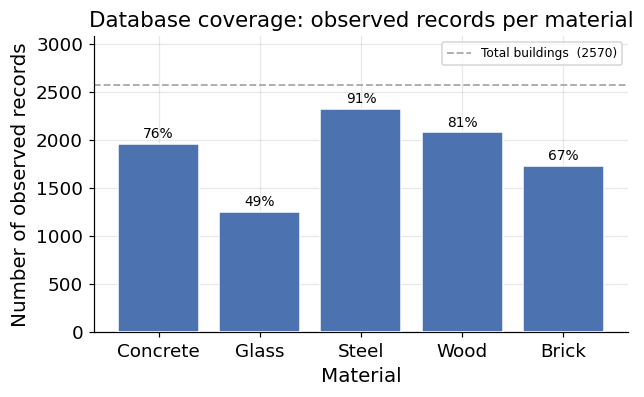

In [186]:
# ==========================================================
# Figure 1 — Database coverage
# ==========================================================

y_all_mask = np.vstack([data["y_train_mask"], data["y_val_mask"], data["y_test_mask"]])
n_total    = len(y_all_mask)
n_obs      = y_all_mask.sum(axis=0)
pct        = n_obs / n_total * 100

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, n_obs, color=_C1, edgecolor="white", zorder=3)
ax.axhline(n_total, color=_GRAY, lw=1.2, ls="--",
           label=f"Total buildings  ({n_total})", zorder=2)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.012,
            f"{p:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Material")
ax.set_ylabel("Number of observed records")
ax.set_title("Database coverage: observed records per material")
ax.set_ylim(0, n_total * 1.20)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 2 Observation model performance by material

AUC-ROC of the Stage 1 observation model on the test set, per material. A higher
AUC indicates the model better distinguishes buildings with a recorded value from
those without. The dashed red line marks the random-classifier baseline (AUC = 0.5).


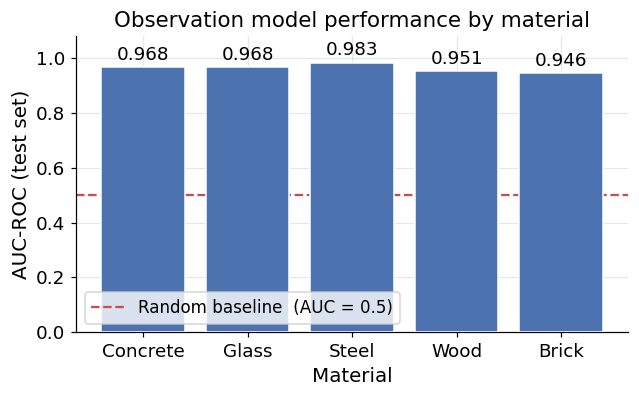

In [187]:
# ==========================================================
# Figure 2 — Observation model performance (AUC)
# ==========================================================

aucs   = [_val(mat, "AUC") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in aucs]
vals   = [v if not pd.isna(v) else 0.0 for v in aucs]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
ax.axhline(0.5, color=_REF, lw=1.5, ls="--",
           label="Random baseline  (AUC = 0.5)", zorder=2)
for bar, v in zip(bars, aucs):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.3f}", ha="center", va="bottom", fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_xlabel("Material", fontsize=13)
ax.set_ylabel("AUC-ROC (test set)", fontsize=13)
ax.set_title("Observation model performance by material", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Figure 3 Conditional reported-intensity model error by material

Mean absolute error (MAE, kg/m²) of the Stage 2 model's median prediction (p50)
against observed reported intensity values on the test set. Only buildings where
the material was recorded are included. Lower MAE indicates more accurate
conditional intensity estimates.


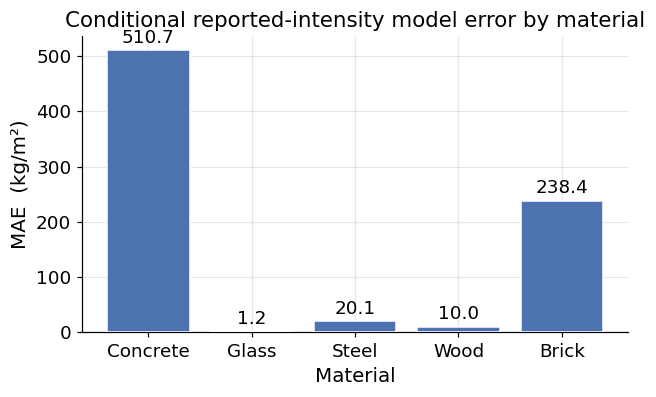

In [188]:
# ==========================================================
# Figure 3 — Conditional intensity model error (MAE)
# ==========================================================

maes   = [_val(mat, "MAE") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in maes]
vals   = [v if not pd.isna(v) else 0.0 for v in maes]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
for bar, v in zip(bars, maes):
    if not pd.isna(v) and v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.012,
                f"{v:.1f}", ha="center", va="bottom", fontsize=12)
ax.set_xlabel("Material", fontsize=13)
ax.set_ylabel("MAE  (kg/m²)", fontsize=13)
ax.set_title("Conditional reported-intensity model error by material", fontsize=14)
plt.tight_layout()
plt.show()


### Figure 4 — Observed vs predicted reported intensity (test set)

Each panel shows observed reported intensity (x-axis) against the model's
median prediction, p50, (y-axis) for buildings where that material was recorded.
Points near the 1:1 reference line indicate accurate predictions.
Log scale is applied where the 5th–95th percentile range spans more than
one order of magnitude.


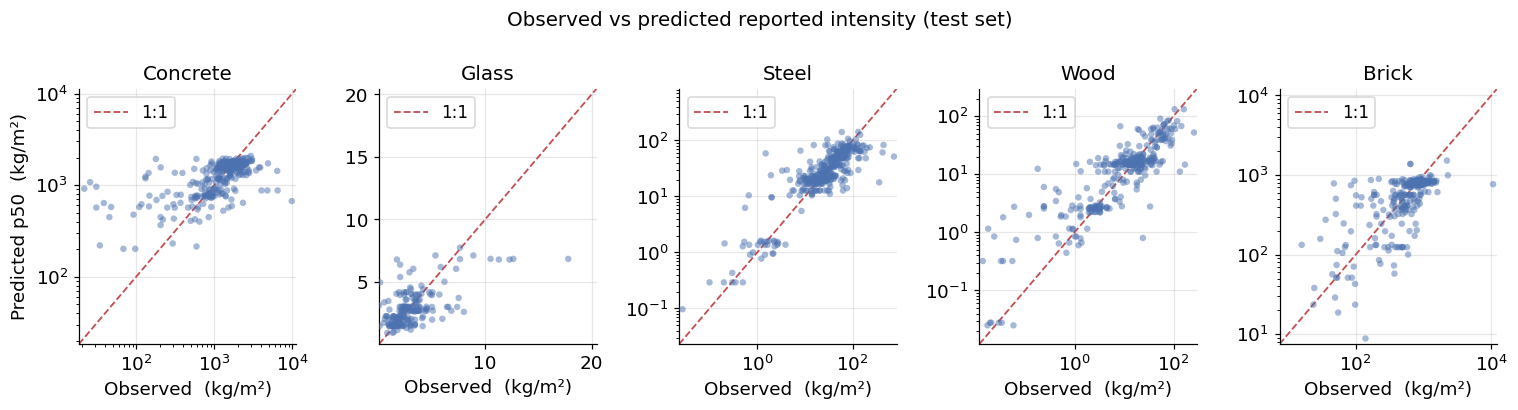

In [189]:
# ==========================================================
# Figure 4 — Observed vs predicted reported intensity
# ==========================================================

fig, axes = plt.subplots(1, len(y_cols), figsize=(14, 3.8))

for ax, m in zip(axes, range(len(y_cols))):
    mat  = y_cols[m]
    obs  = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        ax.text(0.5, 0.5, "insufficient\ndata", transform=ax.transAxes,
                ha="center", va="center", color=_GRAY)
        ax.set_title(mat, fontsize=13)
        continue

    y_true = data["y_test_raw"][obs, m]
    y_pred = intervals_test[mat]["p50"][obs]

    use_log = (len(y_true) > 4 and
               np.percentile(y_true, 95) / (np.percentile(y_true, 5) + 1e-6) > 10)

    ax.scatter(y_true, y_pred, s=18, alpha=0.5, color=_C1, edgecolors="none", zorder=3)

    lo = min(y_true.min(), y_pred.min()) * 0.85
    hi = max(y_true.max(), y_pred.max()) * 1.15
    if use_log:
        lo = max(lo, 1e-2)
    ax.plot([lo, hi], [lo, hi], color=_REF, lw=1.2, ls="--", label="1:1", zorder=2)

    if use_log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(mat, fontsize=13)
    ax.set_xlabel("Observed  (kg/m²)", fontsize=12)
    if m == 0:
        ax.set_ylabel("Predicted p50  (kg/m²)", fontsize=12)
    ax.legend(fontsize=11, loc="upper left")

fig.suptitle("Observed vs predicted reported intensity (test set)", fontsize=13)
plt.tight_layout()
plt.show()


### Figure 5 — Empirical coverage of 90% prediction intervals

Each bar shows the fraction of test-set observations that fall within the model's
predicted 90% interval (p05–p95) for that material. Bars close to the dashed
reference line at 0.90 indicate well-calibrated intervals. Over-coverage (bar > 0.90)
suggests the intervals are too wide; under-coverage suggests they are too narrow.


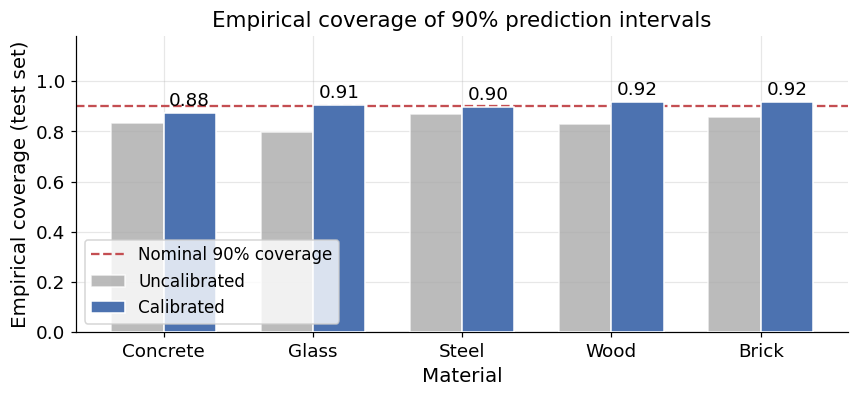

In [190]:
# ==========================================================
# Figure 5 — Empirical interval coverage
# ==========================================================

covs_u = [_val(mat, "CovU") for mat in y_cols]
covs_c = [_val(mat, "CovC") for mat in y_cols]
colors = [(_C1 if abs(v - 0.9) <= 0.1 else _C2) if not pd.isna(v) else _GRAY
          for v in covs_c]
vals_u = [v if not pd.isna(v) else 0.0 for v in covs_u]
vals_c = [v if not pd.isna(v) else 0.0 for v in covs_c]

x = np.arange(len(y_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 3.8))
bars_u = ax.bar(x - width/2, vals_u, width, color=_GRAY,  edgecolor="white",
                label="Uncalibrated", zorder=3, alpha=0.8)
bars_c = ax.bar(x + width/2, vals_c, width, color=colors, edgecolor="white",
                label="Calibrated",   zorder=3)
ax.axhline(0.90, color=_REF, lw=1.5, ls="--",
           label="Nominal 90% coverage", zorder=2)
for bar, v in zip(bars_c, covs_c):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_xticks(x)
ax.set_xticklabels(y_cols, fontsize=12)
ax.set_xlabel("Material", fontsize=13)
ax.set_ylabel("Empirical coverage (test set)", fontsize=13)
ax.set_title("Empirical coverage of 90% prediction intervals", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Figure 6 — Example query output for a single building

This panel illustrates how to interpret `FinalQueryModel.query()` output for one
building from the test set. The **left panel** shows the recording probability
for each material — the estimated chance that the database contains a value for this
building type. The **right panel** shows the conditional reported intensity (bar = p50)
with the 90% prediction interval (error bars); orange dots show the expected reported
intensity, which is the recording probability multiplied by the conditional median.


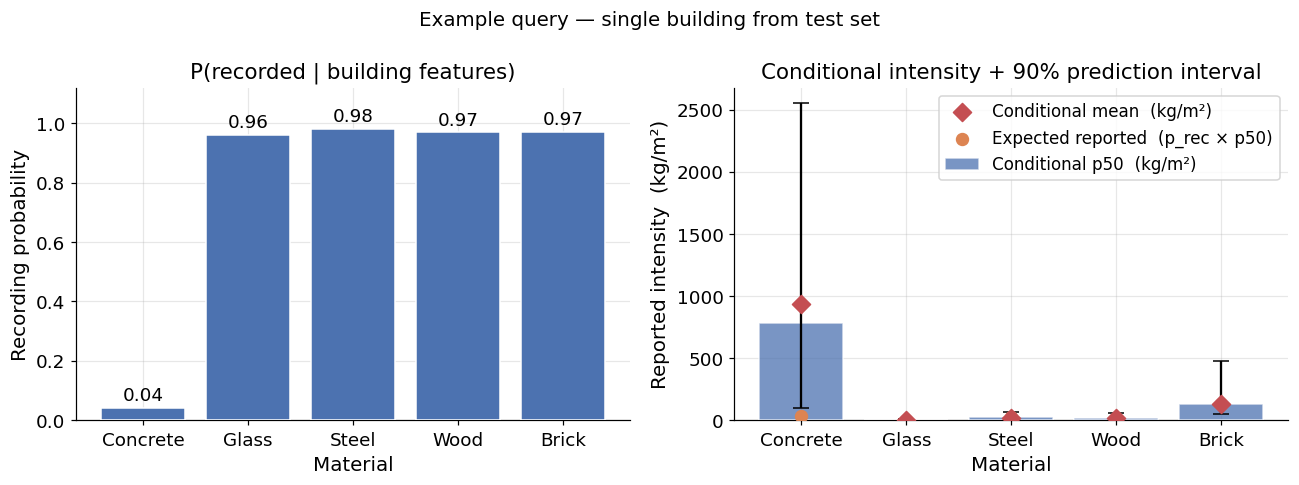


Example building features:
  Construction period: 1999
  Construction period bucket: 1990_2010
  Typology: R-UNK
  Primary Code: S
  Hybrid Structure: 1
  Country: China
  Geo_macro: East Asia

Archetype support in training data: 16 rows (medium)

Predicted intensities (kg/m²):
  Material         p05       p50      mean       p95
  Concrete      100.91    781.81    931.51   2550.61
  Glass           1.42      2.84      2.97      9.17
  Steel           7.63     23.28     21.28     68.60
  Wood            2.64     19.76     16.48     54.13
  Brick          50.18    132.11    129.99    473.75


In [191]:
# ==========================================================
# Figure 6 — Example query output
# ==========================================================

# Pick first test row where at least 3 materials are recorded
example_idx = next(
    (i for i in range(len(data["X_test_proc"]))
     if data["y_test_mask"][i].sum() >= 3),
    0,
)
X_ex     = data["X_test_proc"][example_idx : example_idx + 1]
X_ex_raw = data["X_test_raw"].iloc[example_idx : example_idx + 1][X_cols]
result   = final_query_model.query(X_ex, X_raw=X_ex_raw)

p_rec    = [float(result[mat]["p_recorded"][0])       for mat in y_cols]
p50      = [float(result[mat]["p50"][0])               for mat in y_cols]
p05      = [float(result[mat]["p05"][0])               for mat in y_cols]
p95      = [float(result[mat]["p95"][0])               for mat in y_cols]
mean_val = [float(result[mat]["mean"][0])              for mat in y_cols]
exp_rep  = [float(result[mat]["expected_reported"][0]) for mat in y_cols]
x        = np.arange(len(y_cols))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# -- Left: recording probability --
ax1.bar(y_cols, p_rec, color=_C1, edgecolor="white", zorder=3)
for i, v in enumerate(p_rec):
    ax1.text(i, v + 0.025, f"{v:.2f}", ha="center", fontsize=12)
ax1.set_ylim(0, 1.12)
ax1.set_xlabel("Material", fontsize=13)
ax1.set_ylabel("Recording probability", fontsize=13)
ax1.set_title("P(recorded | building features)", fontsize=14)

# -- Right: conditional intensity + PI --
err_lo = [max(p50[i] - p05[i], 0.0) for i in range(len(y_cols))]
err_hi = [max(p95[i] - p50[i], 0.0) for i in range(len(y_cols))]
ax2.bar(x, p50, color=_C1, alpha=0.75, edgecolor="white",
        label="Conditional p50  (kg/m²)", zorder=3)
ax2.errorbar(x, p50, yerr=[err_lo, err_hi],
             fmt="none", color="black", capsize=5, lw=1.5, zorder=4)
ax2.scatter(x, mean_val, color=_REF, zorder=6, s=70, marker="D",
            label="Conditional mean  (kg/m²)")
ax2.scatter(x, exp_rep, color=_C2, zorder=5, s=60,
            label="Expected reported  (p_rec × p50)")
ax2.set_xticks(x)
ax2.set_xticklabels(y_cols, fontsize=12)
ax2.set_xlabel("Material", fontsize=13)
ax2.set_ylabel("Reported intensity  (kg/m²)", fontsize=13)
ax2.set_title("Conditional intensity + 90% prediction interval", fontsize=14)
ax2.legend(fontsize=11)

fig.suptitle("Example query — single building from test set", fontsize=13)
plt.tight_layout()
plt.show()

# Print building context and archetype support
bldg = data["X_test_raw"].iloc[example_idx]
print("\nExample building features:")
for col in X_cols:
    print(f"  {col}: {bldg[col]}")

archetype_n   = int(result[y_cols[0]]["archetype_n_train"][0])
archetype_lvl = result[y_cols[0]]["archetype_support_level"][0]
print(f"\nArchetype support in training data: {archetype_n} rows ({archetype_lvl})")

print("\nPredicted intensities (kg/m²):")
print(f"  {'Material':<10}  {'p05':>8}  {'p50':>8}  {'mean':>8}  {'p95':>8}")
for i, mat in enumerate(y_cols):
    print(f"  {mat:<10}  {p05[i]:>8.2f}  {p50[i]:>8.2f}  {mean_val[i]:>8.2f}  {p95[i]:>8.2f}")

In [192]:
# ==========================================================
# Save All Application-Required Files
# ==========================================================

import subprocess as _sp
import sys as _sys
import types as _types
import pathlib as _pl

# Step 0a: Export notebook as prediction_model.py (UTF-8)
_result = _sp.run(
    [_sys.executable, "-m", "jupyter", "nbconvert",
     "--to", "script", "prediction_model.ipynb"],
    capture_output=True, text=True,
)
if _result.returncode != 0:
    print("WARNING: nbconvert failed:", _result.stderr[:200])
else:
    print("Generated: prediction_model.py")
    # Ensure UTF-8 encoding — nbconvert may produce UTF-16 on Windows
    _py_path = _pl.Path("prediction_model.py")
    _raw = _py_path.read_bytes()
    if _raw[:2] in (b'\xff\xfe', b'\xfe\xff'):          # UTF-16 with BOM
        _py_path.write_text(_raw.decode('utf-16'), encoding='utf-8')
        print("Re-encoded prediction_model.py: UTF-16 BOM -> UTF-8")
    elif b'\x00' in _raw[:100]:                             # UTF-16 LE without BOM
        _py_path.write_text(_raw.decode('utf-16-le'), encoding='utf-8')
        print("Re-encoded prediction_model.py: UTF-16 LE -> UTF-8")

# Step 0b: Register classes in sys.modules["prediction_model"] WITHOUT importing
# the module file (which would re-execute the entire training pipeline).
# This makes pickle/joblib able to resolve class definitions when the model
# is loaded in a fresh process (e.g. Streamlit).
if "prediction_model" not in _sys.modules:
    _pm = _types.ModuleType("prediction_model")
    _sys.modules["prediction_model"] = _pm
else:
    _pm = _sys.modules["prediction_model"]

_pm.ObservationModel = ObservationModel
_pm.IntensityModel   = IntensityModel
_pm.FinalQueryModel  = FinalQueryModel
ObservationModel.__module__ = "prediction_model"
IntensityModel.__module__   = "prediction_model"
FinalQueryModel.__module__  = "prediction_model"

import json as _json

# 1. Trained model
joblib.dump(final_query_model, "model_finalquery.joblib")
print("Saved: model_finalquery.joblib")

# 2. Preprocessor
joblib.dump(data["preprocessor"], "preprocessor.joblib")
print("Saved: preprocessor.joblib")

# 3. Evaluation results
summary_df.to_csv("evaluation_summary.csv", index=False)
print("Saved: evaluation_summary.csv")

# 4. Model metadata
_model_info = {
    "X_cols":              X_cols,
    "archetype_cols":      archetype_cols,
    "y_cols":              y_cols,
    "SEED":                SEED,
    "LOW_OBS_THRESHOLD":   LOW_OBS_THRESHOLD,
    "n_observed_train":    final_query_model.n_observed_train_,
    "data_split": {
        "n_train": int(len(data["X_train_proc"])),
        "n_val":   int(len(data["X_val_proc"])),
        "n_test":  int(len(data["X_test_proc"])),
    },
}
with open("model_info.json", "w") as _f:
    _json.dump(_model_info, _f, indent=2)
print("Saved: model_info.json")

Generated: prediction_model.py
Saved: model_finalquery.joblib
Saved: preprocessor.joblib
Saved: evaluation_summary.csv
Saved: model_info.json
